# RSI (Relative Strength Index) — AAPL

Wilder's 14-day RSI:

$RSI = 100 - \dfrac{100}{1 + RS}, \quad RS = \dfrac{\text{avg gain}}{\text{avg loss}}$

where avg gain / avg loss are Wilder-smoothed (EMA with α = 1/period). Above 70 = overbought, below 30 = oversold.

In [1]:
import datetime

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
ticker = "AAPL"
start_date = datetime.date(2023, 1, 1)
end_date = datetime.date.today()

period = 14
overbought, oversold = 70, 30

## Download prices

In [3]:
df = yf.download(ticker, start_date, end_date, auto_adjust=True)
df.columns = df.columns.get_level_values(0)  # flatten (field, ticker) MultiIndex
prices = df[["Open", "High", "Low", "Close", "Volume"]].dropna()
prices.tail()

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-09-08,317.100006,320.700012,314.899994,316.220001,35477100
2026-09-09,315.489990,319.149994,309.899994,315.339996,65640000
2026-09-10,316.670013,326.739990,316.510010,326.570007,70011900
2026-09-11,327.450012,336.220001,326.299988,332.269989,50716900
2026-09-14,334.790009,335.500000,331.339996,333.079987,39269100


## Compute RSI

In [4]:
def rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    # Wilder smoothing: EMA with alpha = 1/period
    avg_gain = gain.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    rs = avg_gain / avg_loss
    out = 100 - 100 / (1 + rs)
    return out.where(avg_loss != 0, 100).rename("rsi")  # no losses -> RSI = 100


ind = prices[["Close"]].rename(columns={"Close": "close"})
ind["rsi"] = rsi(ind["close"], period)
ind = ind.dropna()
ind.tail()

Price,close,rsi
Date,,
2026-09-08,316.220001,50.256878
2026-09-09,315.339996,49.401551
2026-09-10,326.570007,58.992827
2026-09-11,332.269989,62.842819
2026-09-14,333.079987,63.369130


In [5]:
# signals: RSI crossing back through the thresholds
ind["signal"] = 0
ind.loc[(ind["rsi"] > oversold) & (ind["rsi"].shift() <= oversold), "signal"] = 1      # exits oversold -> buy
ind.loc[(ind["rsi"] < overbought) & (ind["rsi"].shift() >= overbought), "signal"] = -1  # exits overbought -> sell
ind["signal"].value_counts()

signal
 0    875
-1     28
 1     10
Name: count, dtype: int64

In [6]:
# how much time does AAPL spend in each regime?
regime = pd.cut(ind["rsi"], [0, oversold, overbought, 100], labels=["oversold", "neutral", "overbought"])
regime.value_counts(normalize=True).round(3)

rsi
neutral       0.842
overbought    0.128
oversold      0.030
Name: proportion, dtype: float64

## Plot

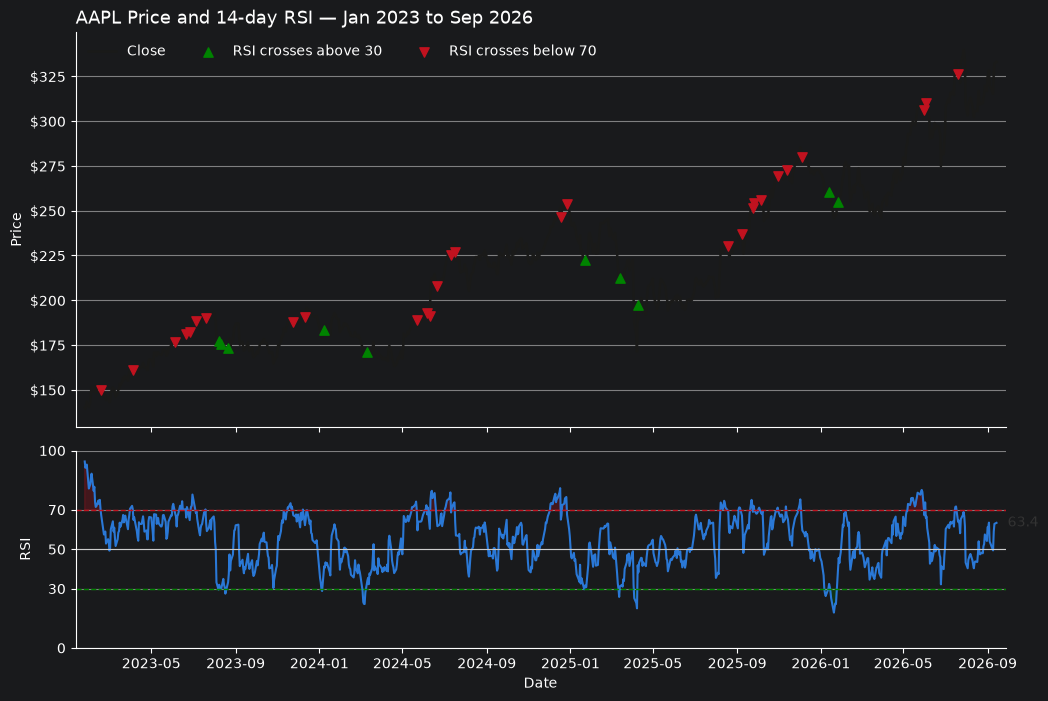

In [7]:
c_price, c_rsi = "#1a1a19", "#2a78d6"

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08}
)

# --- price ---
ax1.plot(ind.index, ind["close"], color=c_price, linewidth=1.8, label="Close")
buys, sells = ind[ind["signal"] == 1], ind[ind["signal"] == -1]
ax1.scatter(buys.index, buys["close"], marker="^", s=45, color="#008300", zorder=3, label=f"RSI crosses above {oversold}")
ax1.scatter(sells.index, sells["close"], marker="v", s=45, color="#c1121f", zorder=3, label=f"RSI crosses below {overbought}")
ax1.set_title(f"{ticker} Price and {period}-day RSI — {ind.index[0]:%b %Y} to {ind.index[-1]:%b %Y}",
              fontsize=13, loc="left")
ax1.set_ylabel("Price")
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax1.legend(loc="upper left", frameon=False, ncol=3)

# --- RSI over time ---
ax2.plot(ind.index, ind["rsi"], color=c_rsi, linewidth=1.5, label=f"RSI({period})")
ax2.axhline(overbought, color="#c1121f", linewidth=1, linestyle="--")
ax2.axhline(oversold, color="#008300", linewidth=1, linestyle="--")
ax2.axhline(50, color="#cccccc", linewidth=0.8)
ax2.fill_between(ind.index, overbought, ind["rsi"], where=ind["rsi"] >= overbought, color="#c1121f", alpha=0.25)
ax2.fill_between(ind.index, oversold, ind["rsi"], where=ind["rsi"] <= oversold, color="#008300", alpha=0.25)
ax2.annotate(f"{ind['rsi'].iloc[-1]:.1f}", xy=(ind.index[-1], ind["rsi"].iloc[-1]), xytext=(8, 0),
             textcoords="offset points", va="center", fontsize=10, color="#333333")
ax2.set_ylim(0, 100)
ax2.set_yticks([0, oversold, 50, overbought, 100])
ax2.set_ylabel("RSI")
ax2.set_xlabel("Date")

for ax in (ax1, ax2):
    ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(x=0.01)

plt.show()